# Personal Last FM Data

* What are my top 10 artist?
* What are my top 10 most listened albums?
* What are my top 10 most listened songs?
* What month is my most listened month?
* What does my daily streamed music looks like?
* What does my comulative streamed music looks like?

first, let's prepare the data:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

user = pd.read_csv('last_fm_user_data.csv')
# Prints first few rows
user.head()

,uts,utc_time,artist,artist_mbid,album,album_mbid,track,track_mbid
0,1774682257,"28 Mar 2026, 07:17","Emerson, Lake & Palmer",NaN,"Welcome Back My Friends, To The Show That Neve...",NaN,"Tarkus - i. Eruption, ii. Stones of Years' iii...",NaN
1,1774434903,"25 Mar 2026, 10:35","Emerson, Lake & Palmer",NaN,"Welcome Back My Friends, To The Show That Neve...",NaN,"Tarkus - i. Eruption, ii. Stones of Years' iii...",NaN
2,1774434284,"25 Mar 2026, 10:24",Camel,2c5eb59f-75a9-44c1-9c40-838d52d375e1,Moonmadness,39824aad-26b8-3c20-b84f-e92949121c91,Lunar Sea,8b7d72c1-3253-4b41-ad8c-dbdd1fca6b35
3,1774433982,"25 Mar 2026, 10:19",Camel,2c5eb59f-75a9-44c1-9c40-838d52d375e1,Moonmadness,39824aad-26b8-3c20-b84f-e92949121c91,Air Born,169f452c-9f17-3712-a25e-c4b691b37b6c
4,1774433567,"25 Mar 2026, 10:12",Camel,2c5eb59f-75a9-44c1-9c40-838d52d375e1,Moonmadness,39824aad-26b8-3c20-b84f-e92949121c91,Another Night,f5c7f4a6-aa79-4bf3-ad39-3ebbc868f33f


In [3]:
# Prints last few rows
user.tail()

,uts,utc_time,artist,artist_mbid,album,album_mbid,track,track_mbid
6149,1730259648,"30 Oct 2024, 03:40",Pink Floyd,83d91898-7763-47d7-b03b-b92132375c47,1965-67 Cambridge St/ation,NaN,See Emily Play - Live in Stockholm 1967,NaN
6150,1730259453,"30 Oct 2024, 03:37",Pink Floyd,NaN,1965-67 Cambridge St/ation,NaN,Set The Controls For The Heart Of The Sun - Li...,NaN
6151,1730259016,"30 Oct 2024, 03:30",Pink Floyd,83d91898-7763-47d7-b03b-b92132375c47,1965-67 Cambridge St/ation,NaN,Scream Thy Last Scream - Live in Stockholm 1967,9be6bff7-8124-428f-be99-b92cfd8fea2a
6152,1730258776,"30 Oct 2024, 03:26",Pink Floyd,83d91898-7763-47d7-b03b-b92132375c47,1965-67 Cambridge St/ation,NaN,Pow R. Toc H. - Live in Stockholm 1967,59b3840a-df0a-4820-8e87-4f8570c80f69
6153,1730258068,"30 Oct 2024, 03:14",Pink Floyd,83d91898-7763-47d7-b03b-b92132375c47,1965-67 Cambridge St/ation,NaN,Matilda Mother - Live in Stockholm 1967,NaN


In [4]:
# Convert to datetime
user['utc_time'] = pd.to_datetime(user['utc_time'])
# Selects rows within 2025 only
user = user[(user['utc_time'] < '2026-01-01') & (user['utc_time'] >= '2025-01-01')]
user



,uts,utc_time,artist,artist_mbid,album,album_mbid,track,track_mbid
856,1767160659,2025-12-31 05:57:00,King Crimson,b38225b8-8e5f-42aa-bcdc-7bae5b5bdab3,Larks' Tongues In Aspic (Expanded & Remastered...,NaN,Larks' Tongues In Aspic (Part II),d69e84b2-341d-407e-8844-d6b25f45256a
857,1767160214,2025-12-31 05:50:00,King Crimson,b38225b8-8e5f-42aa-bcdc-7bae5b5bdab3,Larks' Tongues In Aspic (Expanded & Remastered...,NaN,The Talking Drum,f27a941c-acf4-423b-ad32-a53a3017ec44
858,1767159740,2025-12-31 05:42:00,King Crimson,b38225b8-8e5f-42aa-bcdc-7bae5b5bdab3,Larks' Tongues In Aspic (Expanded & Remastered...,NaN,Easy Money,e22110e3-ed3b-4dae-a643-696cbee97f7d
859,1767159279,2025-12-31 05:34:00,King Crimson,b38225b8-8e5f-42aa-bcdc-7bae5b5bdab3,Larks' Tongues In Aspic (Expanded & Remastered...,NaN,Exiles,edbd56d5-69f7-421b-8ce9-16bca0da6d2c
860,1767159103,2025-12-31 05:31:00,King Crimson,b38225b8-8e5f-42aa-bcdc-7bae5b5bdab3,Larks' Tongues In Aspic (Expanded & Remastered...,NaN,Book of Saturday,61810f64-0f92-439c-9255-b30de805b73c
...,...,...,...,...,...,...,...,...
5183,1735707716,2025-01-01 05:01:00,Genesis,NaN,Genesis Live,bc9fa2ca-8c0f-463e-9629-f34d131c655a,The Knife - Live,NaN
5184,1735707060,2025-01-01 04:51:00,Genesis,NaN,Genesis Live,bc9fa2ca-8c0f-463e-9629-f34d131c655a,Musical Box - Live,NaN
5185,1735706567,2025-01-01 04:42:00,Genesis,NaN,Genesis Live,bc9fa2ca-8c0f-463e-9629-f34d131c655a,GET 'EM OUT BY FRIDAY - Live,NaN
5186,1735706564,2025-01-01 04:42:00,Genesis,NaN,Genesis Live,bc9fa2ca-8c0f-463e-9629-f34d131c655a,The return of the Giant Hogweed - Live,NaN


# 1. What are my Top 10 Artist of 2025?

In [5]:
# See my most listened artist
top_artist = user['artist'].value_counts()[0:10]
top_artist

artist
King Crimson              902
Emerson, Lake & Palmer    842
Pink Floyd                546
The Nice                  533
Genesis                   332
Yes                       169
Gentle Giant               99
The Moody Blues            88
Peter Sinfield             85
Syd Barrett                62
Name: count, dtype: int64

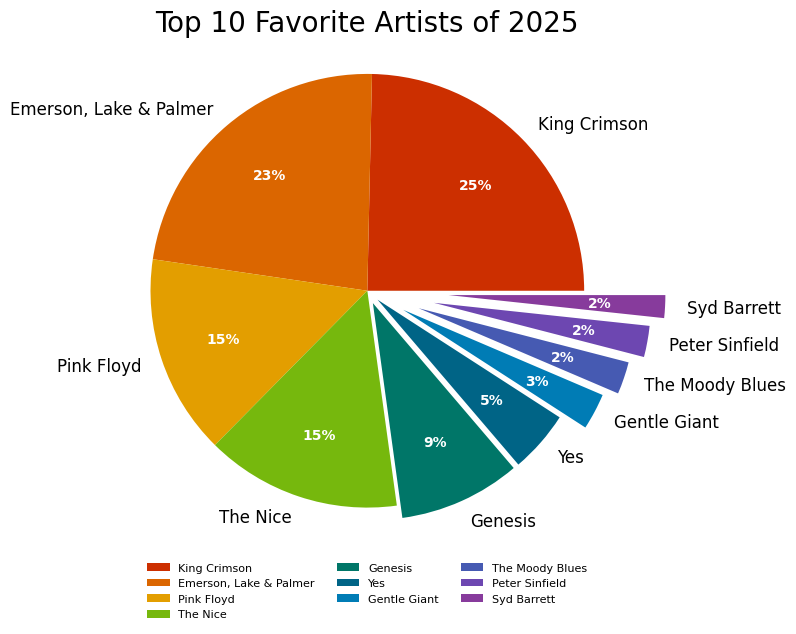

In [10]:
labels = top_artist.index
explode = [0,0,0,0,0.1,0.1,0.3,0.4,0.5,0.6]
colors = ['#CC2F00', '#DB6600', '#E39E00', "#76B80D", '#007668', '#006486', '#007CB5', '#465AB2', '#6D47B1', '#873B9C']




_, texts, autotexts = plt.pie(x=top_artist, labels=labels, explode=explode, autopct='%.0f%%', pctdistance=0.7, labeldistance=1.1, radius=1.6, colors=colors)
# Change percentage label to white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Change font size of text label
for text in texts:
    text.set_fontsize(12)

plt.legend(ncol=3, bbox_to_anchor=(0.5, -.5), loc='lower center', facecolor='none', edgecolor='none')
plt.title('Top 10 Favorite Artists of 2025', pad=65, fontdict={'fontsize':20})
plt.savefig('artist.png', bbox_inches='tight', dpi=300)
plt.show()

# 2. What are my Top 10 Most Listened Albums?

In [11]:
# See my most listened artist
top_album = user['album'].value_counts().head(10)[::-1]
top_album

album
The Thoughts Of Emerlist Davjack                                                93
In The Court Of The Crimson King (Expanded & Remastered Original Album Mix)     94
The Immediate Years CD1                                                         97
Larks' Tongues In Aspic (Expanded & Remastered Original Album Mix)              98
Ars Longa Vita Brevis                                                          106
Trilogy                                                                        125
In the Wake of Poseidon                                                        140
Brain Salad Surgery                                                            173
The Wall                                                                       181
Pictures At an Exhibition (Live) (Deluxe)                                      186
Name: count, dtype: int64

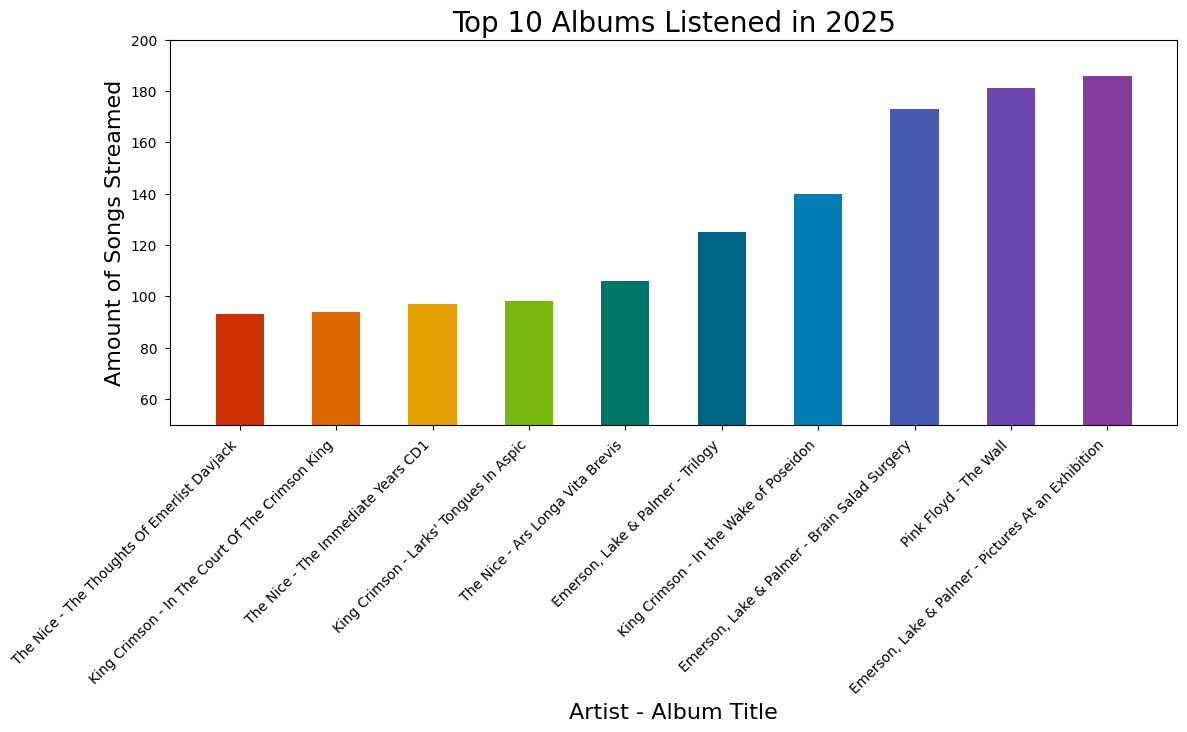

In [12]:
labels = ['The Nice - The Thoughts Of Emerlist Davjack', 'King Crimson - In The Court Of The Crimson King', 'The Nice - The Immediate Years CD1', "King Crimson - Larks' Tongues In Aspic", 'The Nice - Ars Longa Vita Brevis', 'Emerson, Lake & Palmer - Trilogy', 'King Crimson - In the Wake of Poseidon', 'Emerson, Lake & Palmer - Brain Salad Surgery', 'Pink Floyd - The Wall', 'Emerson, Lake & Palmer - Pictures At an Exhibition']
colors = ['#CC2F00', '#DB6600', '#E39E00', "#76B80D", '#007668', '#006486', '#007CB5', '#465AB2', '#6D47B1', '#873B9C']
new_yticks = np.arange(0, top_album.max()+20, 20, dtype=int)

plt.figure(figsize=(13,5))
plt.style.use('seaborn-v0_8-paper')
plt.bar(labels, top_album, width=0.5, color=colors)
plt.title("Top 10 Albums Listened in 2025", fontsize=20)
plt.ylabel("Amount of Songs Streamed", fontsize=16)
plt.xlabel("Artist - Album Title", fontsize=16)

plt.yticks(new_yticks, fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.ylim(50,200)
plt.savefig("top_album.png", bbox_inches='tight', dpi=300)
plt.show()

# 3. What are my Top 10 Most Listened Songs in 2025

In [13]:
top_song = user['track'].value_counts().head(10)[::-1]
top_song

track
Epitaph - Including "March For No Reason" And "Tomorrow And Tomorrow"                                                                       19
Rondo - Live From The Fillmore East,United States Of Amercia/1969                                                                           20
Cadence And Cascade (Greg Lake guide vocal)                                                                                                 20
The Thoughts Of Emerlist Davjack                                                                                                            21
Wholefood Boogie - The Album Mix                                                                                                            23
I Talk to the Wind                                                                                                                          23
Tarkus - i. Eruption, ii. Stones of Years' iii. Iconoclast, iv. Mass, v. Manticore, vi. Battlefield (including Epitaph), vii. Aquatarkus

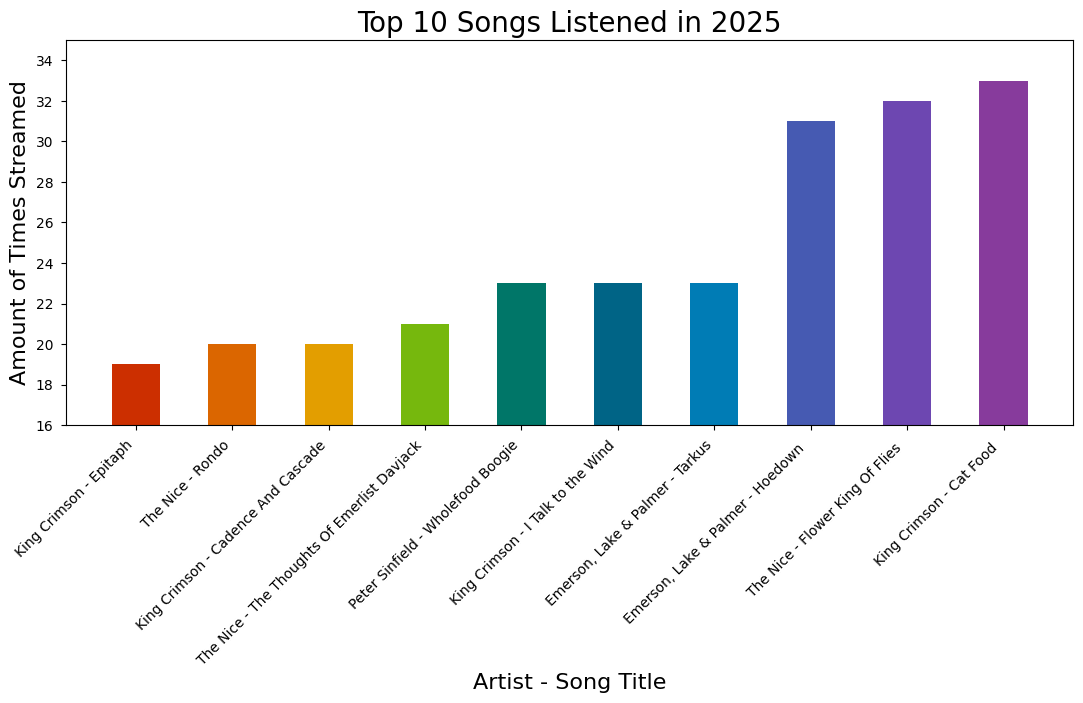

In [72]:
labels = ['King Crimson - Epitaph', 'The Nice - Rondo', 'King Crimson - Cadence And Cascade', 'The Nice - The Thoughts Of Emerlist Davjack', 'Peter Sinfield - Wholefood Boogie', 'King Crimson - I Talk to the Wind', 'Emerson, Lake & Palmer - Tarkus', 'Emerson, Lake & Palmer - Hoedown ', 'The Nice - Flower King Of Flies ', 'King Crimson - Cat Food ']
new_yticks = np.arange(0, top_song.max()+2, 2, dtype=int)


plt.figure(figsize=(13,5))
plt.style.use('seaborn-v0_8-paper')
plt.bar(labels, top_song, width=0.5, color=colors)

plt.title('Top 10 Songs Listened in 2025', fontsize=20)
plt.xlabel('Artist - Song Title', fontsize=16)
plt.ylabel('Amount of Times Streamed', fontsize=16)

plt.yticks(new_yticks, fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.ylim(16,top_song.max()+2)
plt.savefig("top_song.png", bbox_inches='tight', dpi=300)
plt.show()


# 4. What month is my most listened month?

My idea is to get the cumulative amount of listened songs per month via a plot, or get the amount of listened songs per month via a bar chart

In [15]:
song_occurences = user['utc_time'].groupby([user['utc_time'].dt.month]).agg('count')
song_occurences.index = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
song_occurences

January      797
February     823
March        241
April         62
May           98
June           1
July         204
August       639
September    343
October      419
November     395
December     310
Name: utc_time, dtype: int64

I listen to music while commuting to school, so I expect the school months, are the days it would be higher. 
Months where it's summer break, I expected to be lower.




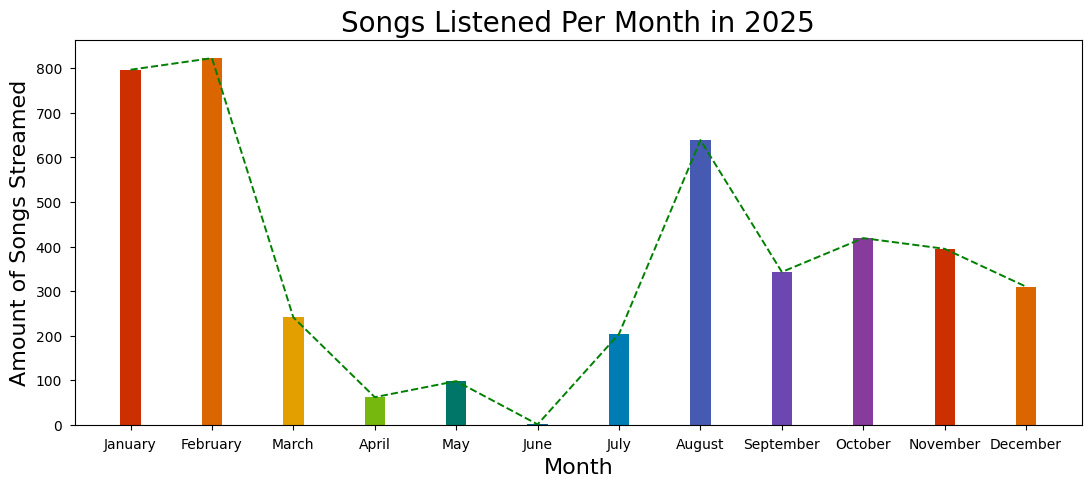

In [16]:
plt.figure(figsize=(13,5))
plt.style.use('seaborn-v0_8-paper')

plt.plot(song_occurences.index, song_occurences, 'g--')
plt.bar(song_occurences.index, song_occurences, width=0.25, color=colors)

plt.title("Songs Listened Per Month in 2025", fontsize=20)
plt.ylabel("Amount of Songs Streamed", fontsize=16)
plt.xlabel("Month", fontsize=16)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig("monthly_listen.png", bbox_inches='tight', dpi=300)
plt.show()

# 4. What day is my most listened?

In [53]:
from calendar import day_name
user['day_name']= user['utc_time'].dt.day_of_week

# Get amount of listening per day
amount_of_listening = user['day_name'].value_counts().sort_index()
amount_of_listening.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Divide to 365 days
per_day = np.round(amount_of_listening / 365, decimals=1)
per_day

Monday       2.2
Tuesday      1.6
Wednesday    2.3
Thursday     1.6
Friday       2.0
Saturday     0.9
Sunday       1.3
Name: count, dtype: float64

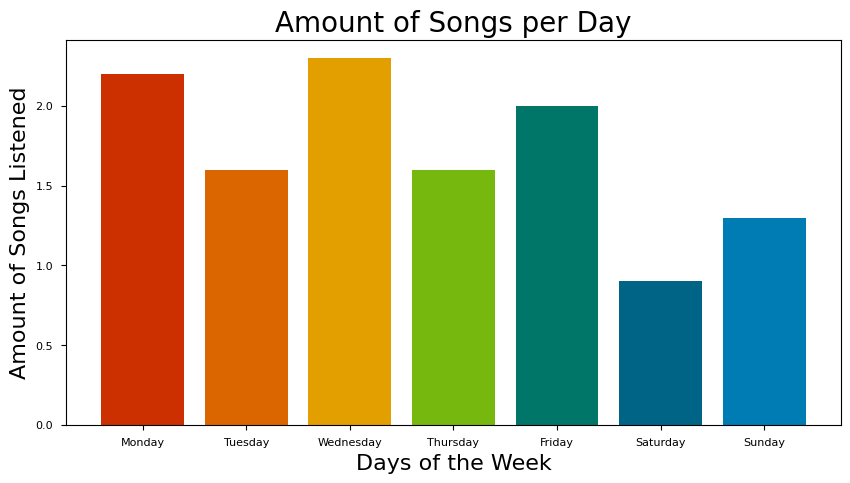

In [73]:
plt.figure(figsize=(10,5))
plt.style.use('seaborn-v0_8-paper')
plt.bar(amount_of_listening.index, per_day, color=colors[:7])

plt.title("Amount of Songs per Day", fontsize=20)
plt.xlabel("Days of the Week", fontsize=16)
plt.ylabel("Amount of Songs Listened", fontsize=16)

plt.savefig("songs_per_day.png", bbox_inches='tight', dpi=300)
plt.show()